In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay

In [5]:
# Create 40 separable points
# np.random.seed(0)
# X = np.r_[np.random.randn(20, 2) - [2, 2], np.random.randn(20, 2) + [2, 2]]
# y = [0] * 20 + [1] * 20

X, y = make_blobs(n_samples=40, centers=2, random_state=6)

In [6]:
# Fit the model
penalty = 1000.0
clf = svm.SVC(kernel="linear", C=penalty)
clf.fit(X, y)

,C,1000.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


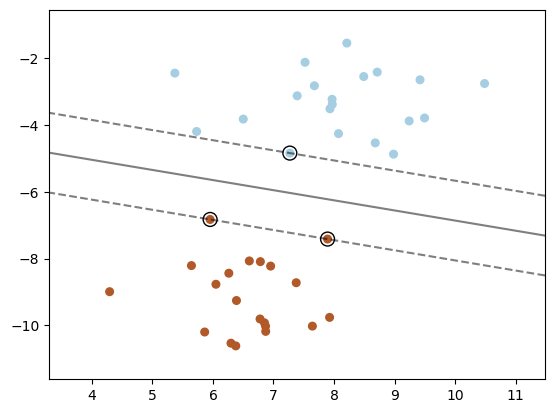

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# plot the decision function
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)
# plot support vectors
ax.scatter(
    clf.support_vectors_[:, 0],
    clf.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors="none",
    edgecolors="k",
)
plt.show()

In [14]:
# Get the separating hyperplane
w = clf.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(2, 12)
# Controls the offset of the hyperplane
yy = a * xx - (clf.intercept_[0]) / w[1]

In [15]:
# Plot the parallels to the separating hyperplane that pass through the
# support vectors (margin away from hyperplane in direction
# perpendicular to hyperplane). This is sqrt(1+a^2) away vertically in
# 2-d.
margin = 1 / np.sqrt(np.sum(clf.coef_**2))
yy_down = yy - np.sqrt(1 + a**2) * margin
yy_up = yy + np.sqrt(1 + a**2) * margin

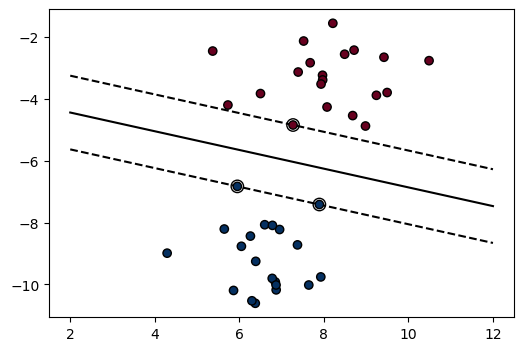

In [ ]:
# Plot the line, the points, and the nearest vectors to the plane
plt.figure(1, figsize=(6, 4))
plt.clf()
plt.plot(xx, yy, "k-")
plt.plot(xx, yy_down, "k--")
plt.plot(xx, yy_up, "k--")

plt.scatter(
    clf.support_vectors_[:, 0],
    clf.support_vectors_[:, 1],
    s=80,
    facecolors="none",
    zorder=10,
    edgecolors="k",
)
plt.scatter(
    X[:, 0], X[:, 1], c=y, zorder=10, cmap=plt.get_cmap("RdBu"), edgecolors="k"
)

YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

In [25]:
# Fit the model
penalty_soft = 0.005
clf_soft = svm.SVC(kernel="linear", C=penalty_soft)
clf_soft.fit(X, y)

# Get the separating hyperplane
w_soft = clf_soft.coef_[0]
a = -w_soft[0] / w_soft[1]
xx_soft = np.linspace(2, 12)
yy_soft = a * xx_soft - (clf_soft.intercept_[0]) / w_soft[1]

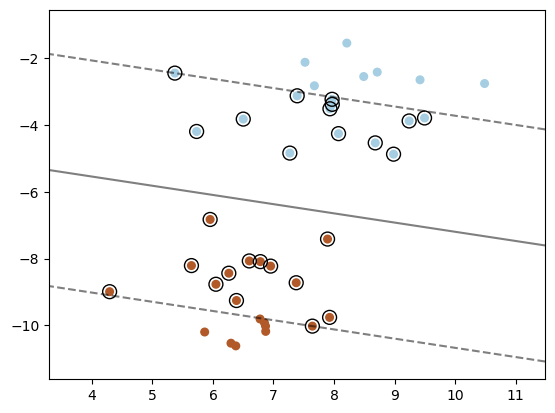

In [26]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# plot the decision function
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf_soft,
    X,
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)
# plot support vectors
ax.scatter(
    clf_soft.support_vectors_[:, 0],
    clf_soft.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors="none",
    edgecolors="k",
)
plt.show()

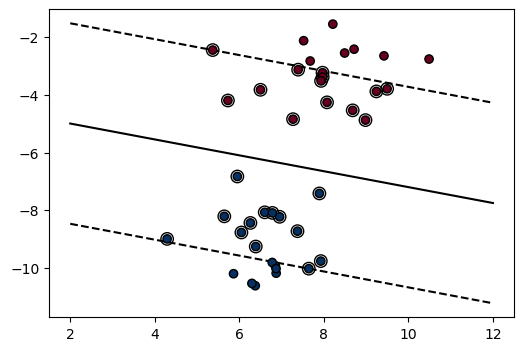

In [27]:
# Plot the parallels to the separating hyperplane that pass through the
# support vectors (margin away from hyperplane in direction
# perpendicular to hyperplane). This is sqrt(1+a^2) away vertically in
# 2-d.
margin = 1 / np.sqrt(np.sum(clf_soft.coef_**2))
yy_down_soft = yy_soft - np.sqrt(1 + a**2) * margin
yy_up_soft = yy_soft + np.sqrt(1 + a**2) * margin

# Plot the line, the points, and the nearest vectors to the plane
plt.figure(1, figsize=(6, 4))
plt.clf()
plt.plot(xx_soft, yy_soft, "k-")
plt.plot(xx_soft, yy_down_soft, "k--")
plt.plot(xx_soft, yy_up_soft, "k--")

plt.scatter(
    clf_soft.support_vectors_[:, 0],
    clf_soft.support_vectors_[:, 1],
    s=80,
    facecolors="none",
    zorder=10,
    edgecolors="k",
)
plt.scatter(
    X[:, 0], X[:, 1], c=y, zorder=10, cmap=plt.get_cmap("RdBu"), edgecolors="k"
)

plt.axis("tight")

YY_soft, XX_soft = np.meshgrid(yy_soft, xx_soft)
xy_soft = np.vstack([XX_soft.ravel(), YY_soft.ravel()]).T
Z_soft = clf_soft.decision_function(xy_soft).reshape(XX_soft.shape)
plt.show()